# Mental Health in the Workplace — Exploratory Data Analysis

---

###  Project Overview

Mental health is one of the most critical yet underreported aspects of workplace well-being. This project performs a structured Exploratory Data Analysis (EDA) on a large-scale survey dataset to uncover patterns, correlations, and actionable insights related to mental health behaviors across different demographics, occupations, and lifestyle factors.

---

### Objectives

1. Identify which demographic and lifestyle factors most influence mental health outcomes
2. Understand what drives treatment-seeking behavior
3. Find patterns between occupation, habits, and emotional well-being
4. Examine how gender influences openness and comfort around mental health discussions
5. Derive actionable recommendations to improve mental health awareness and support systems

---

###  Dataset Description

Timestamp – when the survey was submitted    
Gender – respondent’s gender  
Country – where the respondent lives  
Occupation – their job role  
self_employed – whether the person is self-employed or not  
family_history – if there is any family history of mental health issues  
treatment – whether the person has sought treatment for mental health  
Days_Indoors – how much time the person spends indoors   
Growing_Stress – whether their stress levels are increasing  
Changes_Habits – if their daily habits have changed over time  
Mental_Health_History – past mental health conditions  
Mood_Swings – how frequently their mood changes  
Coping_Struggles – whether they find it difficult to handle stress  
Work_Interest – level of interest in their work  
Social_Weakness – difficulty in social interactions  
mental_health_interview – whether they are comfortable discussing mental health in interviews  
care_options – mental health care options are available at their workplace  

---
##  Importing Libraries and Loading Data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Consistent style and palette
#sns.set_style("whitegrid")
palette = sns.color_palette("Dark2")
sns.set_palette(palette)

# Load the dataset
df = pd.read_csv("Mental Health.csv")

---
## Data Overview

In [2]:
print(df.shape)

(292405, 17)


The dataset contains 292,405 rows and 17 columns.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292405 entries, 0 to 292404
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292405 non-null  object
 1   Gender                   292405 non-null  object
 2   Country                  292404 non-null  object
 3   Occupation               292405 non-null  object
 4   self_employed            287203 non-null  object
 5   family_history           292405 non-null  object
 6   treatment                292405 non-null  object
 7   Days_Indoors             292405 non-null  object
 8   Growing_Stress           292405 non-null  object
 9   Changes_Habits           292405 non-null  object
 10  Mental_Health_History    292405 non-null  object
 11  Mood_Swings              292405 non-null  object
 12  Coping_Struggles         292405 non-null  object
 13  Work_Interest            292405 non-null  object
 14  Social_Weakness     

**Findings :**  
- The dataset is entirely categorical because all columns are of 'object' dtype.
- The Timestamp column is stored as an object due to inconsistent date formats.

In [5]:
df.head(5)

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [ ]:
df.describe(include='all')

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,292405,292405,292404,292405,287203,292405,292405,292405,292405,292405,292405,292405,292405,292405,292405,292405,292405
unique,621,14,43,29,6,3,2,33,3,3,3,4,3,3,3,5,7
top,8/27/2014 11:43,Male,United States,Housewife,No,No,Yes,1-14 days,Maybe,Yes,No,Medium,No,No,Maybe,No,No
freq,2384,239854,171311,66351,258020,176865,147626,63548,99987,109542,104036,101080,154348,105861,103393,232186,118903


Since all features are categorical, df.describe(include='all') provides:
- **count** — non-null values per column  
- **unique** — number of distinct categories  
- **top** — most frequent value  
- **freq** — frequency of the most common value

#### Missing Values

In [ ]:
missing = df.isnull().sum()
missing[missing > 0]

Country             1
self_employed    5202
dtype: int64

Only two columns has missing values. self_employed has 5,202 missing values and country has only 1 missing value.

#### Duplicate Records

In [ ]:
print(df.duplicated().sum())

2313


The dataset contains 2,313 duplicate records, which is only 0.79% of the data, so I will remove it while cleaning the data to avoid skewed analysis.

---
## Data Cleaning and Preprocessing

#### Timestamp
The Timestamp column contains inconsistent mixed date formats. Since I'm focusing on categorical behavioral patterns and not time-series trends,  
I will not use this column further.

#### Gender Standardization

In [ ]:
df.Gender.value_counts()

Gender
Male                 239854
Female                52521
Other                    12
MALE                      4
Non-binary                3
male                      2
 Female                   2
Non-binary (otro)         1
GENDERLESS                1
female                    1
non-binary                1
FEMALE                    1
Care                      1
Gender Fluid              1
Name: count, dtype: int64

The Gender column has many inconsistent and rare labels, so will be cleaning and grouping them into three main categories: Male, Female, and Other.

In [ ]:
df['Gender'] = df['Gender'].str.strip().str.title()
df['Gender'] = df['Gender'].apply(
    lambda x: 'Male' if str(x).startswith('M') 
    else ('Female' if str(x).startswith('F') else 'Other')
)

In [ ]:
df.Gender.value_counts()

Gender
Male      239860
Female     52525
Other         20
Name: count, dtype: int64

After standarization, all the values falls into 'male', 'female' and 'other' category.

#### Yes/No Variants

In [ ]:
df.family_history.value_counts()

family_history
No     176865
Yes    115539
Y           1
Name: count, dtype: int64

In [ ]:
df['family_history'] = df['family_history'].replace({'Y': 'Yes'})
df['self_employed'] = df['self_employed'].replace({'Y': 'Yes', '1': 'Yes'})
df['mental_health_interview'] = df['mental_health_interview'].replace({'TRUE': 'Yes', 'FALSE': 'No'})
df['Mood_Swings'] = df['Mood_Swings'].str.lower().str.capitalize()
df['care_options'] = df['care_options'].replace({'1': 'Yes', 'yes': 'Yes', '0': 'No'})

In [ ]:
df.family_history.value_counts()

family_history
No     176865
Yes    115540
Name: count, dtype: int64

Several columns used different representations for the same values ('Y', 'TRUE', '1', 'yes', etc.).   
So, standardized everything to 'Yes'/'No'/'Maybe'.

#### Handling Missing Values 

In [ ]:
df['self_employed'] = df['self_employed'].fillna('No')

df = df.dropna(subset=['Country'])

Filled missing values in self_employes with 'No' because blank most likely means not self-employed and dropped single row with missing country.

In [ ]:
print(df.isnull().sum().sum())

0


#### Handling invalid entries 

In [ ]:
df.Days_Indoors.value_counts()

Days_Indoors
1-14 days             63548
31-60 days            60705
Go out Every day      58366
More than 2 months    55916
15-30 days            53829
0                         4
8                         2
9                         2
14                        2
30                        2
5                         2
2                         2
12                        2
7                         2
15                        2
31                        1
22                        1
6                         1
19                        1
21                        1
17                        1
61                        1
1000                      1
3                         1
18                        1
25                        1
45                        1
999                       1
23                        1
60                        1
100                       1
-1                        1
4                         1
Name: count, dtype: int64

In [ ]:
# convert everything to string and clean
df['Days_Indoors'] = df['Days_Indoors'].astype(str).str.strip().str.lower()

# function to standardize values
def clean_days(value):
    if value in ['1-14 days', '15-30 days', '31-60 days']:
        return value
    elif value in ['go out every day']:
        return 'Go out every day'
    elif value in ['more than 2 months']:
        return 'More than 2 months'
    
    # handle numeric values
    elif value.isdigit():
        num = int(value)
        if 1 <= num <= 14:
            return '1-14 days'
        elif 15 <= num <= 30:
            return '15-30 days'
        elif 31 <= num <= 60:
            return '31-60 days'
        elif num > 60:
            return 'More than 2 months'
    
    return None  # invalid values

# apply cleaning function
df['Days_Indoors'] = df['Days_Indoors'].apply(clean_days)

# drop rows where value becomes none
df = df.dropna(subset=['Days_Indoors'])

# Final check
print(df['Days_Indoors'].value_counts())

Days_Indoors
1-14 days             63565
31-60 days            60708
Go out every day      58366
More than 2 months    55920
15-30 days            53840
Name: count, dtype: int64


The column had a few inconsistent numeric values along with the main categories,   
so I grouped them into proper categories and removed the invalid ones.

#### Removing Duplicates

In [ ]:
#Removing duplicates
df = df.drop_duplicates()

#resetting the index
df = df.reset_index(drop=True)

print(f"Remaining duplicates: {df.duplicated().sum()}")

Remaining duplicates: 0


#### Basic Cleaning of Categorical Columns

In [ ]:
cat_cols = [
    'Gender', 'Country', 'Occupation', 'self_employed', 'family_history',
    'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits',
    'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles',
    'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options'
]

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

I removed extra spaces from categorical columns to ensure consistency.

**The dataset is cleaned and prepared for analysis.**  
The main steps included:   
- Handling missing values
- Removing duplicate records (2,313 rows)
- Standardizing categorical values (Gender and Yes/No columns)
- Cleaning and grouping Days_Indoors values
- Removing invalid entries
- Trimming extra spaces from categorical columns

---
## Exploratory Data Analysis

---

## A] Univariate Analysis
**Question: What is the distribution of individual variables?**

### Gender Distribution

In [ ]:
df['Gender'].value_counts()

Gender
Male      237909
Female     52160
Other         17
Name: count, dtype: int64

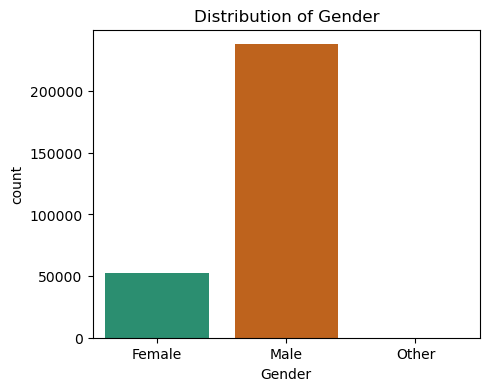

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(data = df, x = 'Gender', hue = 'Gender');
plt.title('Distribution of Gender')
plt.show()

**Insight:**  
We can see that most respondents are male, with fewer females and very few in the “Other” category. This shows a clear imbalance in the dataset.

### Treatment Distribution

In [ ]:
df['treatment'].value_counts()

treatment
Yes    146201
No     143885
Name: count, dtype: int64

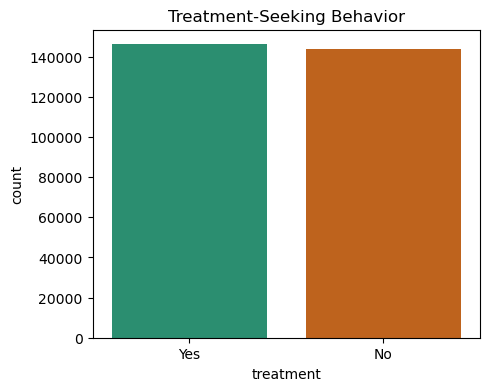

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(x='treatment', data=df, hue='treatment')
plt.title("Treatment-Seeking Behavior")
plt.show()

**Insight:**  
We can see a nearly balanced distribution between individuals who took treatment (Yes) and the individuals who did not (No).

### Growing Stress Distribution

In [ ]:
df['Growing_Stress'].value_counts()

Growing_Stress
Maybe    99302
Yes      98790
No       91994
Name: count, dtype: int64

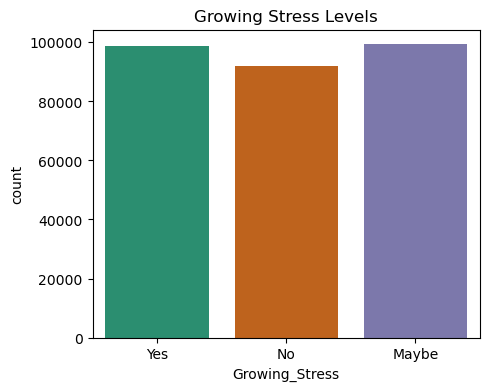

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Growing_Stress', data=df,hue='Growing_Stress')
plt.title("Growing Stress Levels")
plt.show()

**Insight:**  
We can see that the stress is quite evenly distributed, but the high number of “Maybe” responses stands out.  
This shows that many people aren’t completely sure about their stress levels.

### Distribution of Mental Health History

In [ ]:
df.Mental_Health_History.value_counts()

Mental_Health_History
No       103329
Maybe     94516
Yes       92241
Name: count, dtype: int64

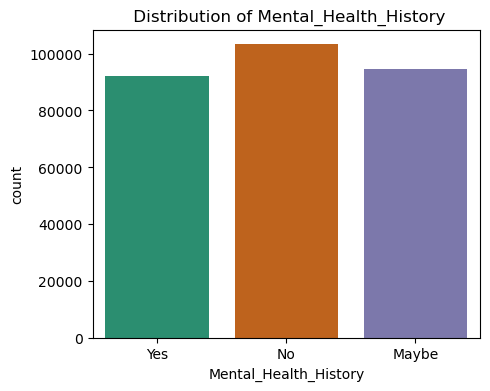

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Mental_Health_History', data=df,hue='Mental_Health_History')
plt.title(" Distribution of Mental_Health_History")
plt.show()

**Insights :**  
Plot shows that maximum individuals in our dataset does not have a history of mental health followed by 'maybe'.

### Occupation Distribution

In [ ]:
df.Occupation.value_counts()

Occupation
Housewife    65906
Student      61268
Corporate    60683
Others       52410
Business     49819
Name: count, dtype: int64

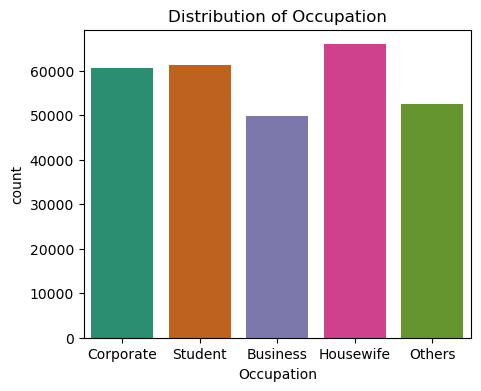

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Occupation', data=df,hue='Occupation')
plt.title("Distribution of Occupation")
plt.show()

**Insights :**  
We can see that there are maximum housewives in the dataset followed by student and corporate. 

---
## B] Bivariate Analysis
**Question: How do pairs of variables relate to each other?**

### Does family history influence treatment-seeking behavior?

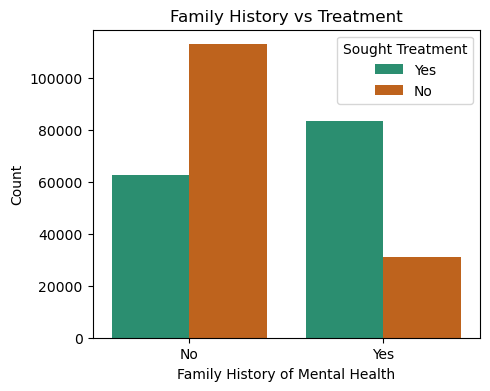

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(x='family_history', hue='treatment', data=df)
plt.title("Family History vs Treatment")
plt.xlabel("Family History of Mental Health")
plt.ylabel("Count")
plt.legend(title='Sought Treatment')
plt.show()

**Insight:**  
We can see that family history has a strong influence on treatment-seeking behavior.  
People with a family history of mental health issues are more likely to seek treatment.  
People without a family history are less likely to seek professional help.  

This suggests that prior exposure to mental health conversations within the family increases awareness and makes individuals more proactive about seeking help.

### Does staying indoors increase stress levels?

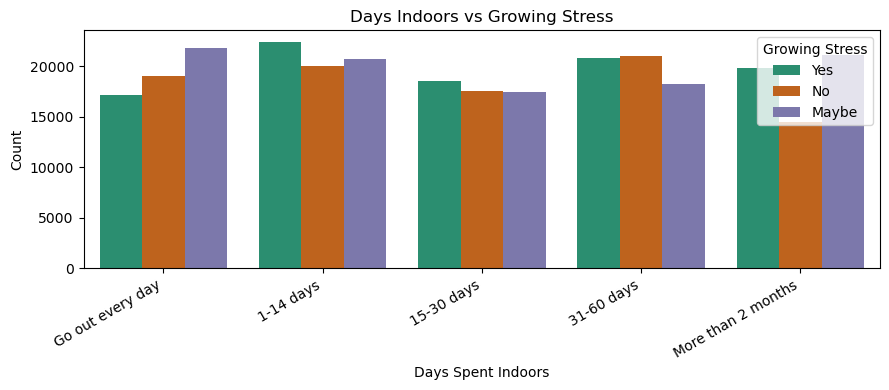

In [ ]:
# Define a logical order for the x-axis
indoors_order = ['Go out every day', '1-14 days', '15-30 days', '31-60 days', 'More than 2 months']

plt.figure(figsize=(9, 4))
sns.countplot(x='Days_Indoors', hue='Growing_Stress', data=df, order=indoors_order)
plt.xticks(rotation=30,ha='right')
plt.title("Days Indoors vs Growing Stress")
plt.xlabel("Days Spent Indoors")
plt.ylabel("Count")
plt.legend(title='Growing Stress')
plt.tight_layout()
plt.show()

**Insight:**  
We can see that there is no strong or clear relationship between days spent indoors and growing stress levels.  
Stress responses (Yes, No, Maybe) are fairly evenly distributed across all indoor-duration categories.  
Even people who go out daily report stress, while some staying indoors for longer periods do not.  
This suggests that physical isolation alone does not determine stress.

### Does occupation affect mood swings?

In [ ]:
df.Occupation.value_counts()

Occupation
Housewife               65906
Student                 61268
Corporate               60683
Others                  52375
Business                49819
Teacher                     5
Software Engineer           4
Administrator               2
Lawyer                      2
Scientist                   2
Doctor                      2
Nurse                       2
Data Scientist              2
Unknown                     1
Analyst                     1
Engineer                    1
Manager                     1
Programmer                  1
Designer                    1
Engineer; Manager           1
Sales Representative        1
Data Analyst                1
Accountant                  1
Tech Lead                   1
Software Developer          1
Care worker                 1
Consultant                  1
Name: count, dtype: int64

In [ ]:
threshold = 10

# get value counts
counts = df['Occupation'].value_counts()

 # replace rare categories with 'Others'
df['Occupation'] = df['Occupation'].apply(
     lambda x: x if counts[x] >= threshold else 'Others')
print(df['Occupation'].value_counts())

Occupation
Housewife    65906
Student      61268
Corporate    60683
Others       52410
Business     49819
Name: count, dtype: int64


Small categories were combined into “Others” to make the analysis cleaner.

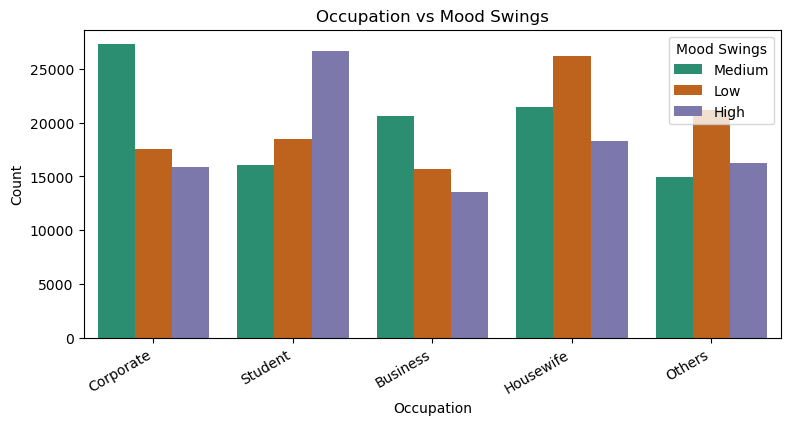

In [ ]:
plt.figure(figsize=(9, 4))
sns.countplot(x='Occupation', hue='Mood_Swings', data=df)
plt.xticks(rotation=30, ha='right')
plt.title("Occupation vs Mood Swings")
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.legend(title='Mood Swings')
plt.show()

**Insight:**  
Corporate employees have more medium mood swings.   
Students show a higher count of high mood swings, which could be due to academic pressure and uncertainty.    
Housewives show higher count of low mood swings, which shows relatively stable emotional patterns.  
Business professionals also lean more towards medium mood swings.  
The “Others” category is a bit mixed but shows slightly higher low mood swings.  

### Does social weakness affects coping struggles?

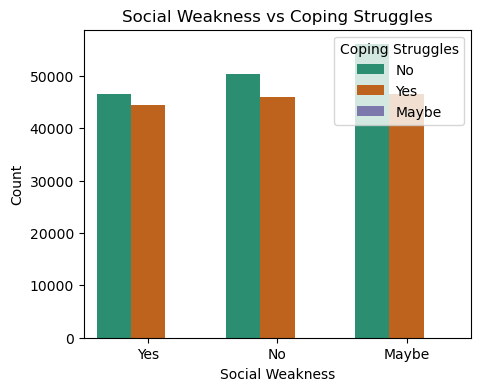

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Social_Weakness', hue='Coping_Struggles', data=df)
plt.title("Social Weakness vs Coping Struggles")
plt.xlabel("Social Weakness")
plt.ylabel("Count")
plt.legend(title='Coping Struggles')
plt.show()

**Insight :**  
We can see that individuals with, without or unsure about social weakness, shows almost a balance between difficulty in  
handling stress and able to handle stress. However, we can see that mostly they are not having difficulty.

### Which Gender is more comfortable in talking about mental health?

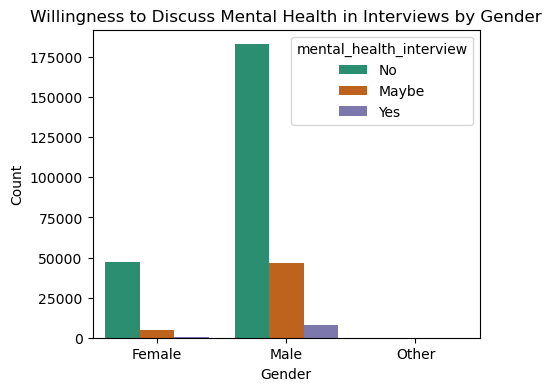

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Gender', hue='mental_health_interview', data=df)
plt.title('Willingness to Discuss Mental Health in Interviews by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='mental_health_interview')
plt.show()

**Insights :**  
We can see that no gender is comfortable in discussing mental health.

---
### C] Multivariate Analysis
**Question: How do multiple variables interact simultaneously to explain mental health outcomes?**

### Does family history and occupation together predict treatment rates?
I want to check whether the effect of family history on treatment changes depending on what kind of job you have.

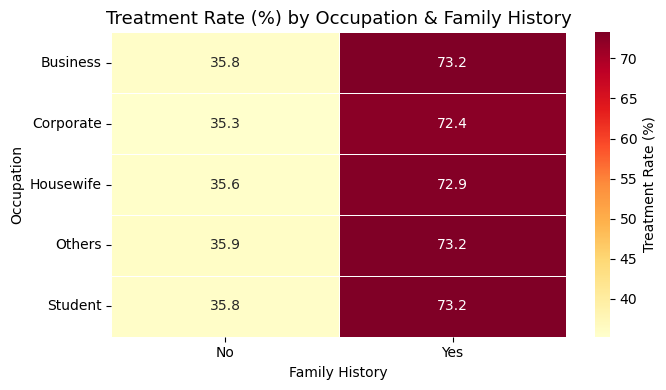

In [ ]:
treat_pct = (
    df.groupby(['Occupation', 'family_history'])['treatment']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
)
treat_pct.columns = ['Occupation', 'Family_History', 'Treatment_Rate_%']

pivot = treat_pct.pivot(index='Occupation', columns='Family_History', values='Treatment_Rate_%')

plt.figure(figsize=(7, 4))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, cbar_kws={'label': 'Treatment Rate (%)'}
)
plt.title("Treatment Rate (%) by Occupation & Family History", fontsize=13)
plt.xlabel("Family History")
plt.ylabel("Occupation")
plt.tight_layout()
plt.show()

**Insight:**    
We can see that treatment rate almost doubles across all occupations, when there is a family history of mental health.  
Occupation barely matters here, because we can see that there is barely any difference in treatment rates within each   
group of family history.  
This shows that treatment seeking depends on prior exposure to mental health and not on what job you are in.

### Which combination of lifestyle factors is most associated with growing stress?
Will be checking how changes in habits and mental health history jointly affect the likelihood of reporting growing stress.

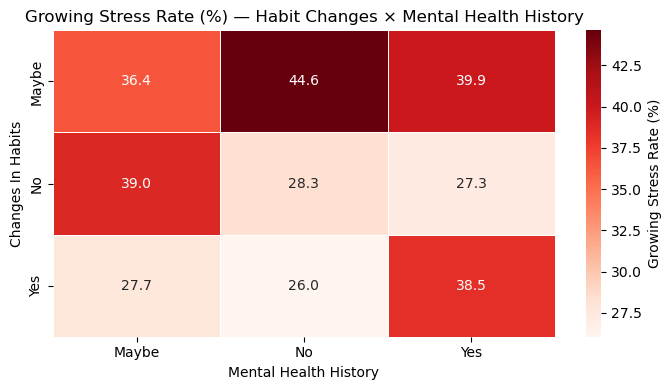

In [ ]:
stress_pct = (
    df.groupby(['Changes_Habits', 'Mental_Health_History'])['Growing_Stress']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
)
stress_pct.columns = ['Changes_Habits', 'Mental_Health_History', 'Stress_Rate_%']

pivot_s = stress_pct.pivot(
    index='Changes_Habits',
    columns='Mental_Health_History',
    values='Stress_Rate_%'
)

plt.figure(figsize=(7, 4))
sns.heatmap(
    pivot_s, annot=True, fmt='.1f', cmap='Reds',
    linewidths=0.5, cbar_kws={'label': 'Growing Stress Rate (%)'}
)
plt.title("Growing Stress Rate (%) — Habit Changes × Mental Health History", fontsize=12)
plt.xlabel("Mental Health History")
plt.ylabel("Changes In Habits")
plt.tight_layout()
plt.show()

**Insights :**  
We can conclude from the heatmap that indiviuals with no history of mental health and have changed their habbits,  
reports least growth in stress.  
Individuals with no mental health history and who are unsure about their habbits, reports maximum stress.  
We can also see that indivials who are unsure about their habbits, reports growth in their stress  
whether they have history of mental health or not.  
This shows that uncertainity in lifestyle, not clearly recognizing your own life, leads to stress.

---
## Conclusion

---

- Family history is the biggest factor in seeking help. People who have a family history of mental health issues are significantly more likely to seek treatment. This makes sense because when someone grows up around conversations about mental health, they're more aware and less afraid to reach out.
- Your job doesn't really change whether you seek treatment. The heatmap showed that treatment rates nearly doubled when family history was present, regardless of occupation. Whether you're in corporate, a student, or a housewife,family background matters far more than your job type.
- Students experience the most mood swings. Compared to other groups, students showed the highest levels of high mood swings. Academic pressure, uncertainty about the future, and lifestyle instability likely play a big role here.
- Being unsure about your own habits is a stress trigger. People who weren't sure whether their daily habits had changed reported the highest stress levels, even more than those who clearly had changed habits. This suggests that a lack of self-awareness or uncertainty about one's own lifestyle is more stressful than the change itself.
- Staying indoors doesn't directly cause stress. Surprisingly, the number of days spent indoors had no clear pattern with growing stress. People who went out every day also reported stress, while some long-term indoor dwellers didn't. So physical isolation alone isn't the issue.
- Nobody is comfortable talking about mental health in interviews. Across all genders, people were largely unwilling to discuss mental health in a professional interview setting. This points to a widespread stigma that still exists in workplaces.
- Most respondents don't have a formal mental health history. The majority reported no past mental health conditions, though a notable chunk fell in the "Maybe" category, which could reflect either self-doubt or simply not having been formally diagnosed.
- The dataset is male-dominated. Most survey respondents were male, which means some findings (especially around gender-based comfort with mental health discussions) should be interpreted with that imbalance in mind.

---
## Prescriptions / Recommendations

---

- Since family history is the strongest driver of treatment-seeking, awareness programs should target families — not just individuals. If mental health is normalized at home from an early age, people are more likely to seek help when they need it.
- Students showed the highest mood swings in the dataset. Schools and colleges should have accessible counseling, peer support groups, and stress management workshops — not just during exam season, but year-round.
- Corporate workers showed consistent medium mood swings. Companies should normalize mental health days, provide confidential counseling access, and train managers to recognize early signs of burnout.
- The data showed that people who were unsure about their habits reported the most stress. Simple tools like journaling, habit trackers, or even periodic personal check-ins can help people stay aware of their lifestyle changes before stress builds up.
- Nobody (male, female, or other) felt comfortable talking about mental health in any kind of interview or open conversation. This shows that people still hesitate to open up about it, fearing judgment. Encouraging open and non-judgmental conversations, whether at school, workplace, or community level, can help people feel safer and confident about expressing their mental health struggles.
- Target the "Maybe" responders. A large chunk of people answered "Maybe" across several questions (stress, habits, mental health history). These individuals are in a gray zone — they may be struggling but haven't acknowledged it yet. Gentle outreach, anonymous self-assessment tools, and low-barrier counseling options could help this group the most.